_____
еще больше интересного __в моём telegram канале:__ https://t.me/ml_maxim
_____

In [7]:
%autosave 60

Autosaving every 60 seconds


In [8]:
import warnings
warnings.filterwarnings('ignore')

# 1. Градиент

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

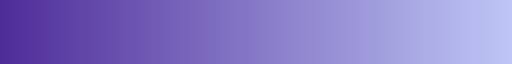

In [10]:
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'my_cmap', [
        "#4F2D99",  "#BFC6F6",
    ]
)

custom_cmap

In [11]:
# Определяем целевую функцию
def f(x, y):
    return x**2 + y**2

# Градиент функции
def gradient(x, y):
    return np.array([2*x, 2*y])

# Реализация градиентного спуска
def gradient_descent(starting_point, learning_rate, num_iterations):
    point = np.array(starting_point, dtype=np.float64)
    path = [point.copy()]
    
    for _ in range(num_iterations):
        grad = gradient(point[0], point[1])
        point -= learning_rate * grad
        path.append(point.copy())
    
    return np.array(path)

In [6]:
# Параметры градиентного спуска
starting_point = [3, 3]
learning_rate = 0.1
num_iterations = 5

# Получаем путь градиентного спуска
path = gradient_descent(starting_point, learning_rate, num_iterations)

# Создаем сетку для изолиний
x = np.linspace(-4, 4, 10)
y = np.linspace(-4, 4, 10)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

In [7]:
path = np.array(
    [
        [3.     , 3.5     ],
        [3.4    , 1.4    ],
        [1.92   , 1.92   ],
        [1.36  , 1.  ],
        [0., 0.]
    ]
)

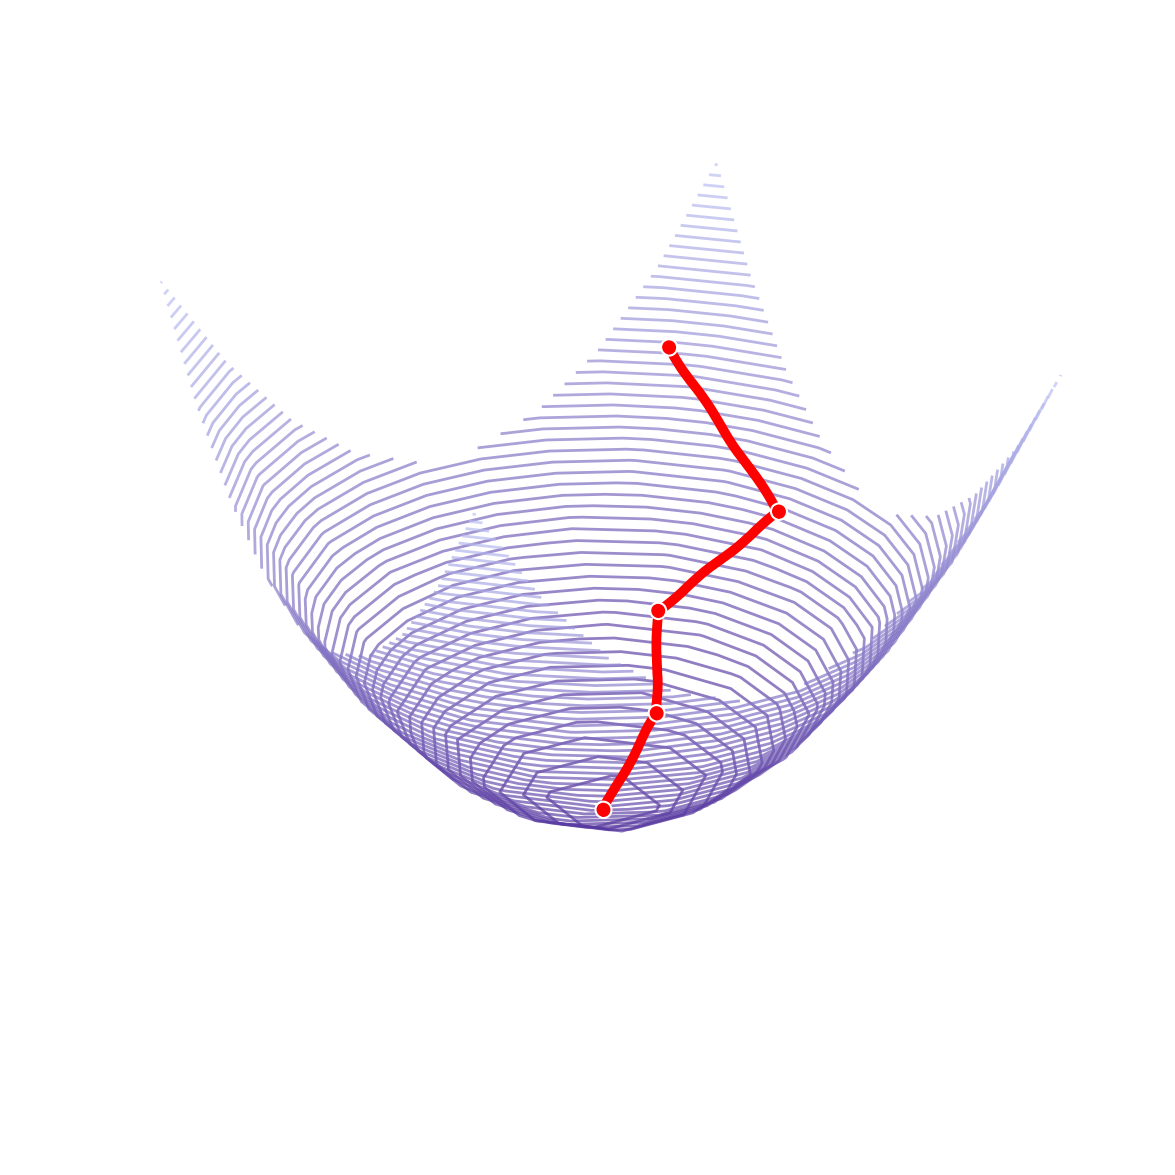

In [8]:
# Визуализация
plt.xkcd()
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# Изолинии
ax.contour3D(X, Y, Z, levels=60, cmap=custom_cmap, alpha=0.7, zorder=0, linewidth=9)

# Путь градиентного спуска
ax.plot(path[:, 0], path[:, 1], f(path[:, 0], path[:, 1]), color='r', 
        marker='o', markersize=9, 
        zorder=12, linewidth=7)

# Установка угла визуализации
ax.view_init(elev=25, azim=240)

plt.axis('off')
plt.show()
# plt.savefig(
#     '../imgs_habr/gradient_d.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, transparent=True
# )

# 2. Спуск

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
plt.xkcd()
plt.rcParams["figure.facecolor"] = "#BFC6F6"
plt.rcParams["axes.facecolor"] = "#BFC6F6"
plt.rcParams['savefig.facecolor'] = "#BFC6F6"

In [11]:
def J(theta):
    return (theta**2 - 1.5)**2 + 0.5 * theta

In [12]:
# Параметры
theta_vals = np.linspace(-2., 2, 400)
learning_rates = [
    [0.1, 0.1], [0.9, 0.1]
]
n_iters = 6
colors = ['red', 'black']
labels = ['Learning Rate небольшой', 'Learning Rate большой']
initial_theta = 1.

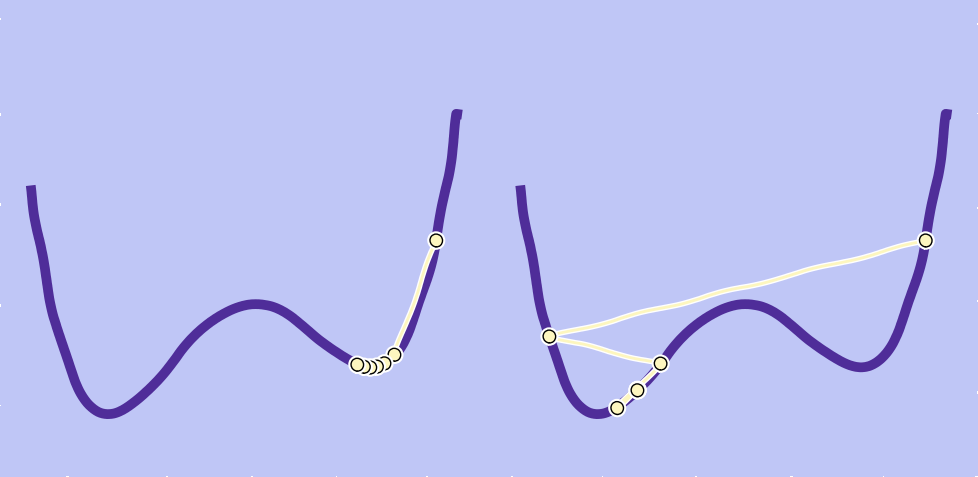

In [13]:
# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, lr in enumerate(learning_rates):
    initial_theta = 1.8
    theta = initial_theta
    trajectory = [theta]
    
    for idx in range(n_iters):
        theta = theta - (np.sign((2 * theta * (theta**2 - 1) + 0.5)) * np.linspace(*lr, n_iters)[idx] * J(theta))
        trajectory.append(theta)

    axes[i].plot(theta_vals, J(theta_vals), 'b-', color="#4F2D99", linewidth=7)
    axes[i].plot(
        trajectory, J(np.array(trajectory)), 
        'ro-', 
        linewidth=2, 
        color='#FDF6BF',
        marker='o', markersize=9,
        markeredgecolor='black', # цвет обводки маркеров
    )
    
    axes[i].grid(False)
    axes[i].axis('off')
    axes[i].set_ylim(-2, 10)

plt.tight_layout()

plt.show()

# plt.savefig(
#     '../imgs_habr/learning_2.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, 
#     transparent=True
# )

# 3. Байес

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

In [15]:
# Целевая функция
def objective_function(x):
    return np.sin(x) + 0.1 * np.random.randn(*x.shape)

In [16]:
# Настройка начальных данных
X_init = np.array([[0], [10]])
y_init = objective_function(X_init)

# Настройка пространства поиска
X = np.linspace(-1, 10, 100).reshape(-1, 1)
y_true = np.sin(X)

# Создание гауссовского процесса с ядром Матерна
kernel = Matern(nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1**2)
lers = [3, 2, 3]

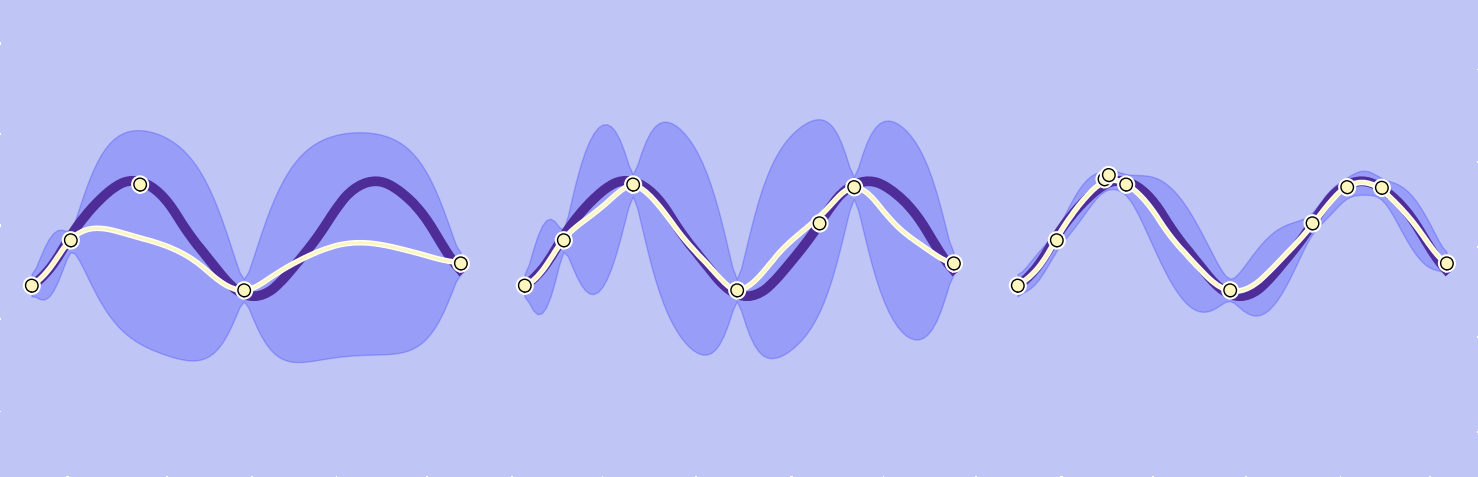

In [17]:
# Создаем графики
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    
    for _ in range(lers[i]):
        for _ in range(3):
            gp.fit(X_init, y_init)
    
        # Предсказание и получение доверительных интервалов
        y_pred, sigma = gp.predict(X, return_std=True)
        y_pred = y_pred.squeeze()

        # Выбор новой точки для аппроксимации - метод UCB
        acquisition = y_pred + 1.96 * sigma
        next_point = X[np.argmax(acquisition)]

        # Добавление новой точки выборки
        X_init = np.vstack((X_init, next_point))
        y_init = np.append(y_init, objective_function(next_point))

    # Визуализация истинной функции
    ax.plot(X, y_true, 'b-', color="#4F2D99", linewidth=7)
    
    # Визуализация предсказания гауссовского процесса
    ax.plot(X, y_pred, 'b-', linewidth=2, color='#FDF6BF')
    
    ax.fill_between(X.ravel(), 
                    y_pred.squeeze() - 1.96*sigma, 
                    y_pred.squeeze() + 1.96*sigma, 
                    alpha=0.2, color='b')
    
    # Исходные и новые точки выборки
    ax.plot(
        X_init, y_init,
        'r.', 
        linewidth=2, 
        color='#FDF6BF', # C0C6F2 # FDF6BF   # F9DC8C
        marker='o', markersize=9,
        markeredgecolor='black', # цвет обводки маркеров
    )
    ax.set_ylim(-4, 4)
    ax.grid(False)
    ax.axis('off')

plt.tight_layout()
plt.show()

# plt.savefig(
#     '../imgs_habr/bayes_1.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, 
# #     transparent=True
# )

# 4. Линейная регрессия

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
import matplotlib.patheffects as path_effects

In [13]:
plt.rcParams["figure.facecolor"] = "#BFC6F6"
plt.rcParams["axes.facecolor"] = "#BFC6F6"
plt.rcParams['savefig.facecolor'] = "#BFC6F6"

In [14]:
# Генерация случайных данных
np.random.seed(3)

X = 2 * np.random.rand(12, 1)
y = 4 + 3 * X + np.random.randn(12, 1)

vv = [3, 3, 10]

In [15]:
# Функция для отображения графиков
def plot_iteration(ax, model, X, y, title):
    ax.plot(
        X, y,
        'r.', 
        linewidth=2, 
        color='#FDF6BF',
        marker='o', 
        markersize=14,
        markeredgecolor='black',
        zorder=12
    )
    
    # Предсказанные значения
    X_new = np.array([[X.min()], [X.max()]])
    y_pred = model.predict(X_new)
    ax.plot(X_new, y_pred, 'b-', color="#4F2D99", linewidth=7)
    
    # Расчет и отображение перпендикуляров и ошибок
    total_error = 0
    for i in range(len(X)):
        y_proj = model.predict(X[i].reshape(1, -1))
        error = abs(y[i] - y_proj)
        total_error += error
        
        # Отображение перпендикуляров
        ax.plot([X[i], X[i]], [y[i], y_proj], 'k--', lw=2, alpha=0.5, color="#4F2D99")
        
        # Отображение ошибок для четных точек
        if i % 2 == 0:
            txt = ax.text(X[i]-0.1, (y[i]), f'{error[0]:.2f}', fontsize=12, color='#4F2D99', zorder=12, fontweight='bold')
            txt.set_path_effects([path_effects.Stroke(linewidth=1, foreground='white'),
                                  path_effects.Normal()])

    print(f'{title}\nобщая ошибка: {total_error[0]:.1f}')
    
    ax.grid(False)
    ax.axis('off')
    ax.set_ylim(1, 13)
    
    ax.set_yticks([])
    ax.set_xticks([])

итерация 1
общая ошибка: 39.1
итерация 2
общая ошибка: 20.3
итерация 3
общая ошибка: 10.3


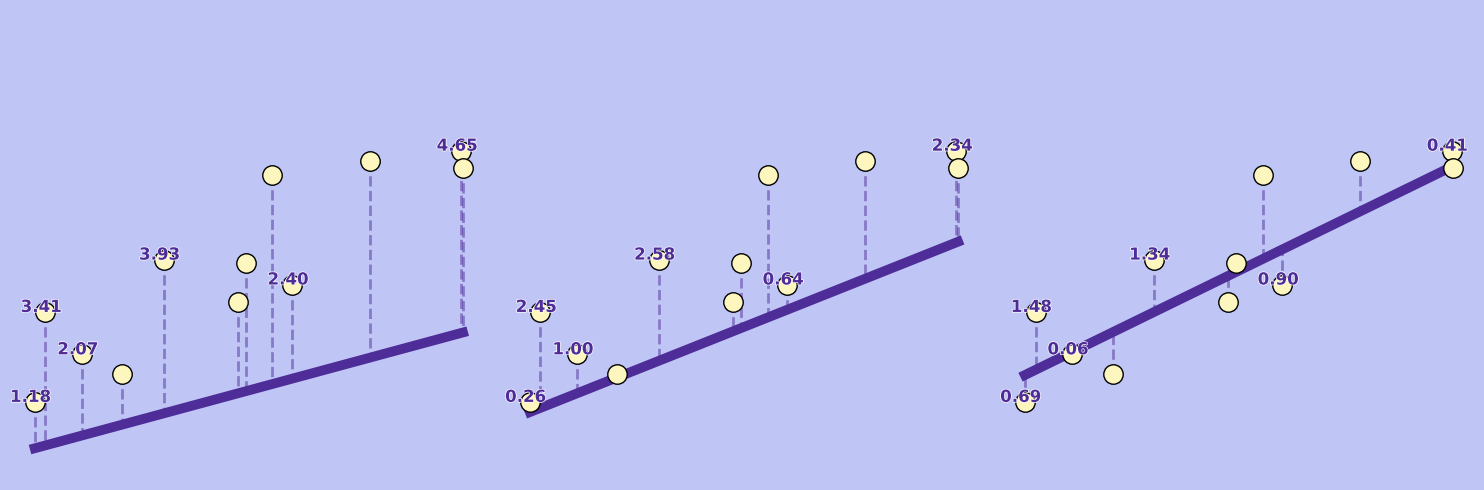

In [16]:
# Создаем 3 подграфика
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Инициализация модели линейной регрессии c итеративным обучением
model = SGDRegressor(max_iter=1, tol=None, eta0=0.01, learning_rate='constant', penalty='l2', alpha=0.1, random_state=0)

# Обучение и визуализация первых трех итераций
for i, ax in enumerate(axes):
    for _ in range(vv[i]):
        model.partial_fit(X, y.ravel())
    plot_iteration(ax, model, X, y, f'итерация {i + 1}')

# Отображение графиков
plt.tight_layout()
plt.show()

# plt.savefig(
#     '../imgs_habr/esr_error_1.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, 
# #     transparent=True
# )

# 5. Оверфит под сердечко

In [23]:
import scipy
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor

In [24]:
x = np.linspace(-2, 2, 1000)
y1 = np.sqrt(1-(abs(x)-1) ** 2)
y2 = -3 * np.sqrt(1-(abs(x)/2) ** 0.5)

In [25]:
n_vals_list = [2, 100, 1000]

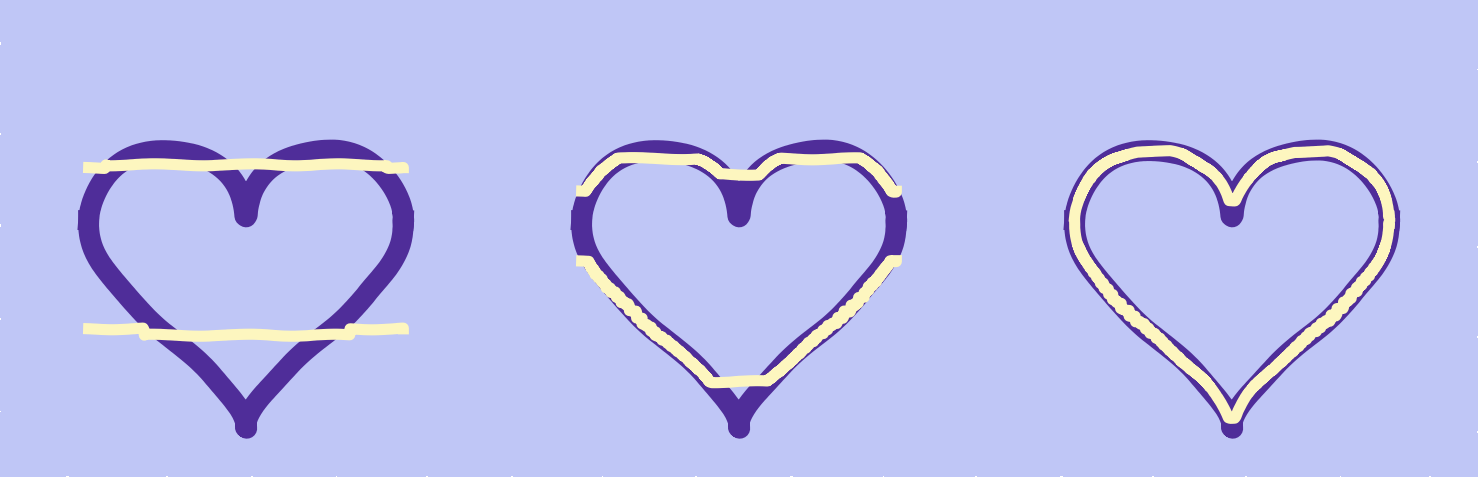

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):

    model_1 = GradientBoostingRegressor(max_depth=1, n_estimators=n_vals_list[i], random_state=0)
    model_1 = model_1.fit(list(zip(x, x**3)), y1)
    y1_pred = model_1.predict(list(zip(x, x**3)))

    model_2 = GradientBoostingRegressor(max_depth=1, n_estimators=n_vals_list[i], random_state=0)
    model_2 = model_2.fit(list(zip(x, x**3)), y2)
    y2_pred = model_2.predict(list(zip(x, x**3)))

    ax.plot(x, y1, color="#4F2D99", linewidth=15)
    ax.plot(x, y2, color="#4F2D99", linewidth=15)

    ax.plot(x, y1_pred, color="#FDF6BF", linewidth=8)
    ax.plot(x, y2_pred, color="#FDF6BF", linewidth=8)

    ax.grid(False)
    ax.axis('off')
    ax.set_ylim(-3.5, 3)
    ax.set_xlim(-3, 3)
    
    ax.set_yticks([])
    ax.set_xticks([])
    
    
# Отображение графиков
plt.tight_layout()
plt.show()

# plt.savefig(
#     '../imgs_habr/heart_trees_3.png',
#     dpi=150, format='png', bbox_inches='tight', pad_inches=0, 
# #     transparent=True
# )